<a href="https://colab.research.google.com/github/OPIM5512-yhi24001/myscrapers-yhi24001-v2/blob/main/Model_Tending_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Price Prediction Model — Performance Dashboard

**Model:** Random Forest with Optuna Hyperparameter Tuning  
**Features:** year, mileage, make, model, transmission, color, city, state, zip_code  
**Pipeline:** Hourly scrape → LLM extraction → Materialize CSV → Train → Predict → Sync to GitHub  

---
This notebook tracks:
1. **Model Accuracy** — MAE, MAPE, RMSE, Bias over time
2. **Feature Importance** — Permutation importance
3. **Partial Dependence Plots** — How top features influence predictions
4. **Dataset Growth** — How performance changes as data accumulates
5. **Prediction Analysis** — Actual vs Predicted deep dive

## 1. Setup & Imports

In [1]:
!git clone https://github.com/OPIM5512-yhi24001/myscrapers-yhi24001-v2.git
import os
os.chdir('myscrapers-yhi24001-v2')
print(os.getcwd())
print(os.listdir('./results'))

Cloning into 'myscrapers-yhi24001-v2'...
remote: Enumerating objects: 1207, done.
remote: Counting objects: 100% (391/391), done.
remote: Compressing objects: 100% (335/335), done.
remote: Total 1207 (delta 212), reused 211 (delta 54), pack-reused 816 (from 1)
Receiving objects: 100% (1207/1207), 5.51 MiB | 13.41 MiB/s, done.
Resolving deltas: 100% (518/518), done.
/content/myscrapers-yhi24001-v2
['2026041003-preds.csv', '2026041013-preds.csv', '2026040916-preds_llm.csv', '2026040914-preds_llm.csv', '2026041123-preds_llm.csv', '2026041115-preds.csv', '2026041113-preds_llm.csv', '2026041006-preds_llm.csv', '2026040923-preds_llm.csv', '2026041106-preds_llm.csv', '2026041104-preds.csv', '2026040903-preds_llm.csv', '2026041015-preds.csv', '2026040904-preds.csv', '2026040921-preds.csv', '2026040912-preds.csv', '2026041122-preds_llm.csv', '2026040911-preds.csv', '2026040914-preds.csv', '2026041103-preds.csv', '2026040918-preds_llm.csv', '2026041021-preds_llm.csv', '2026041011-preds.csv', '20

In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='darkgrid', palette='muted')

# ── CONFIG: path to results/ folder (relative to repo root) ──
RESULTS_DIR = './results'

print('✅ Imports OK')
print(f'📂 Results dir: {os.path.abspath(RESULTS_DIR)}')

✅ Imports OK
📂 Results dir: /content/myscrapers-yhi24001-v2/results


## 2. Load All Prediction Files

In [3]:
def load_all_preds(results_dir, pattern='*-preds_llm.csv'):
    """
    Load all preds_llm.csv files synced from GCP.
    Each file = one hourly run.
    Filename format: YYYYMMDDHHM-preds_llm.csv

    Expected columns:
      post_id, scraped_at, make, model, year, mileage, price,
      transmission, color, state, zip_code, city,
      actual_price, pred_price
    """
    files = sorted(glob.glob(os.path.join(results_dir, pattern)))
    if not files:
        print(f'No files found matching {pattern} in {results_dir}')
        print('Make sure you are running from the repo root.')
        return pd.DataFrame()

    dfs = []
    for f in files:
        run_id = os.path.basename(f).replace('-preds_llm.csv', '')
        try:
            df = pd.read_csv(f)
            df['run_id'] = run_id
            df['run_ts'] = pd.to_datetime(run_id, format='%Y%m%d%H', errors='coerce')
            dfs.append(df)
        except Exception as e:
            print(f'  Skipping {f}: {e}')

    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    for col in ['actual_price', 'pred_price', 'year', 'mileage']:
        combined[col] = pd.to_numeric(combined[col], errors='coerce')

    print(f'Loaded {len(files)} prediction files → {len(combined)} total rows')
    print(f'Date range: {combined["run_ts"].min()} → {combined["run_ts"].max()}')
    return combined


preds_df = load_all_preds(RESULTS_DIR)
if not preds_df.empty:
    display(preds_df.head(3))

Loaded 46 prediction files → 10898 total rows
Date range: 2026-04-09 03:00:00 → 2026-04-11 23:00:00


,post_id,scraped_at,make,model,year,mileage,price,transmission,color,state,actual_price,pred_price,run_id,run_ts,zip_code,city
0,7922872400,2026-04-09T03:00:35Z,chrysler,crossfire,2004,93000.0,7500.0,automatic,unknown,unknown,7500.0,12815.47,2026040903,2026-04-09 03:00:00,NaN,NaN
1,7922888909,2026-04-09T03:00:35Z,Dodge,Neon,2002,150000.0,3288.0,automatic,unknown,unknown,3288.0,12318.10,2026040903,2026-04-09 03:00:00,NaN,NaN
2,7922899953,2026-04-09T01:00:39Z,subaru,forester,2023,113437.0,19900.0,automatic,unknown,unknown,19900.0,13207.24,2026040903,2026-04-09 03:00:00,NaN,NaN


## 3. Compute Metrics Per Run

- **MAE** — Mean Absolute Error (avg dollar error)
- **RMSE** — Root Mean Squared Error (penalizes large errors more)
- **MAPE** — Mean Absolute Percentage Error (error as % of actual price)
- **Bias** — Positive = model over-predicts, Negative = under-predicts

In [4]:
def compute_metrics(df):
    records = []
    for (run_id, run_ts), grp in df.groupby(['run_id', 'run_ts']):
        valid = grp[grp['actual_price'].notna() & grp['pred_price'].notna()].copy()
        if len(valid) < 2:
            continue
        actual = valid['actual_price'].values
        pred   = valid['pred_price'].values
        errors = pred - actual
        mae    = float(np.mean(np.abs(errors)))
        rmse   = float(np.sqrt(np.mean(errors ** 2)))
        mask   = actual != 0
        mape   = float(np.mean(np.abs(errors[mask] / actual[mask])) * 100) if mask.any() else np.nan
        bias   = float(np.mean(errors))
        records.append({'run_id': run_id, 'run_ts': run_ts, 'n_preds': len(valid),
                        'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Bias': bias})

    out = pd.DataFrame(records).sort_values('run_ts').reset_index(drop=True)
    print(f'Computed metrics for {len(out)} runs')
    if not out.empty:
        l = out.iloc[-1]
        print(f'\nLatest run  →  MAE: ${l["MAE"]:,.0f}  |  RMSE: ${l["RMSE"]:,.0f}  |  MAPE: {l["MAPE"]:.1f}%  |  Bias: ${l["Bias"]:+,.0f}')
        print(f'Best MAE ever: ${out["MAE"].min():,.0f}  (run {out.loc[out["MAE"].idxmin(), "run_id"]})')
    return out


if not preds_df.empty:
    metrics_df = compute_metrics(preds_df)
    display(metrics_df.tail(5))
else:
    metrics_df = pd.DataFrame()

Computed metrics for 46 runs

Latest run  →  MAE: $7,332  |  RMSE: $16,370  |  MAPE: 110.0%  |  Bias: $-372
Best MAE ever: $6,872  (run 2026041009)


,run_id,run_ts,n_preds,MAE,RMSE,MAPE,Bias
41,2026041119,2026-04-11 19:00:00,250,7118.448000,16356.160507,104.604052,-576.840320
42,2026041120,2026-04-11 20:00:00,255,7362.339137,16795.734186,106.210214,-728.300863
43,2026041121,2026-04-11 21:00:00,259,7314.143205,16569.645991,106.706342,-615.380270
44,2026041122,2026-04-11 22:00:00,263,7313.041369,16395.316077,109.224554,-414.986084
45,2026041123,2026-04-11 23:00:00,266,7332.321128,16370.107294,109.951713,-371.790902


## 4. Model Accuracy Over Time

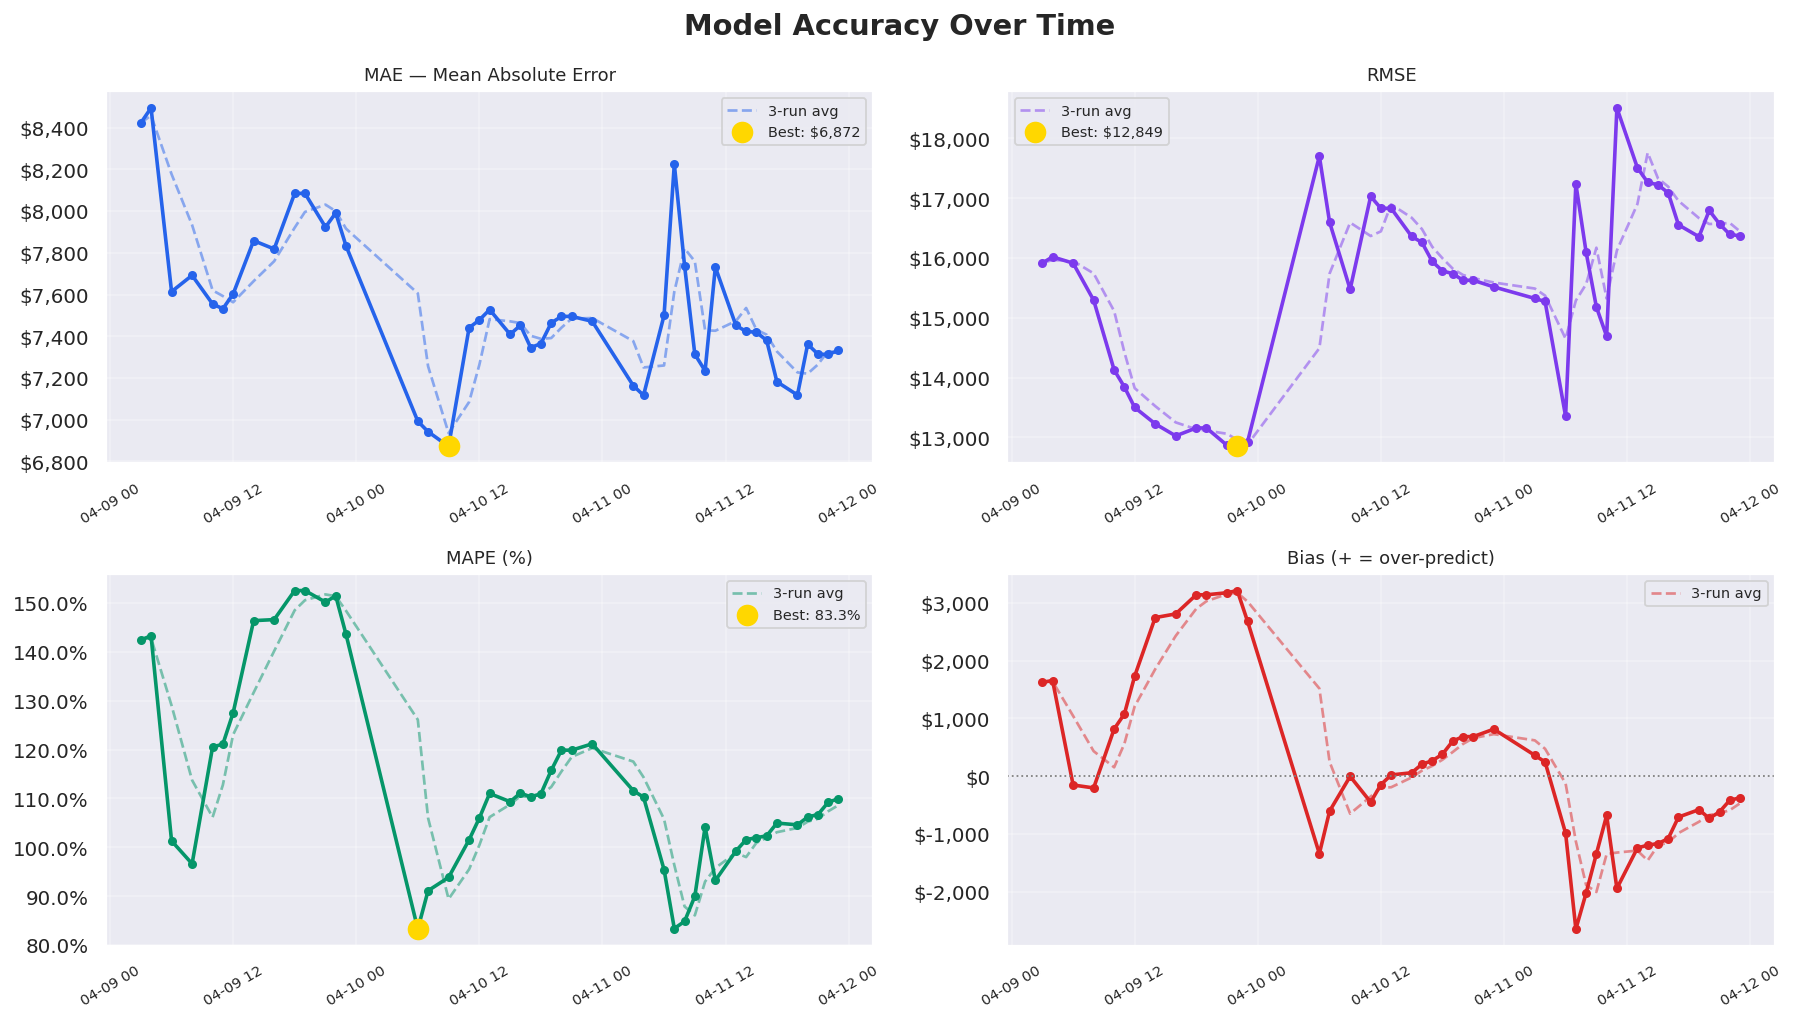

Saved dashboard_accuracy.png


In [5]:
def plot_accuracy_over_time(metrics_df):
    if metrics_df.empty:
        print('No metrics to plot yet.')
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Model Accuracy Over Time', fontsize=16, fontweight='bold')
    dollar_fmt = FuncFormatter(lambda x, _: f'${x:,.0f}')
    pct_fmt    = FuncFormatter(lambda x, _: f'{x:.1f}%')

    items = [
        ('MAE',  'MAE — Mean Absolute Error',  '#2563eb', dollar_fmt),
        ('RMSE', 'RMSE',                        '#7c3aed', dollar_fmt),
        ('MAPE', 'MAPE (%)',                    '#059669', pct_fmt),
        ('Bias', 'Bias (+ = over-predict)',     '#dc2626', dollar_fmt),
    ]

    for ax, (col, title, color, fmt) in zip(axes.flatten(), items):
        valid = metrics_df[metrics_df[col].notna()]
        ax.plot(valid['run_ts'], valid[col], color=color, linewidth=2, marker='o', markersize=4)
        if len(valid) >= 3:
            roll = valid[col].rolling(3, min_periods=1).mean()
            ax.plot(valid['run_ts'], roll, color=color, linewidth=1.5,
                    linestyle='--', alpha=0.5, label='3-run avg')
            ax.legend(fontsize=8)
        if col != 'Bias':
            best_idx = valid[col].idxmin()
            ax.scatter(valid.loc[best_idx, 'run_ts'], valid.loc[best_idx, col],
                       color='gold', s=120, zorder=5,
                       label=f'Best: {fmt(valid.loc[best_idx, col], None)}')
            ax.legend(fontsize=8)
        if col == 'Bias':
            ax.axhline(0, color='gray', linewidth=1, linestyle=':')
        ax.set_title(title, fontsize=10)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dashboard_accuracy.png'), bbox_inches='tight', dpi=130)
    plt.show()
    print('Saved dashboard_accuracy.png')


plot_accuracy_over_time(metrics_df)

## 5. Performance Summary Table

In [6]:
def summary_table(metrics_df):
    if metrics_df.empty:
        print('No data yet.')
        return
    l = metrics_df.iloc[-1]
    summary = pd.DataFrame({
        'Metric':      ['MAE', 'RMSE', 'MAPE', 'Bias', 'Predictions'],
        'Latest Run':  [f'${l["MAE"]:,.0f}', f'${l["RMSE"]:,.0f}', f'{l["MAPE"]:.1f}%',
                        f'${l["Bias"]:+,.0f}', f'{l["n_preds"]:.0f}'],
        'Best Ever':   [f'${metrics_df["MAE"].min():,.0f}', f'${metrics_df["RMSE"].min():,.0f}',
                        f'{metrics_df["MAPE"].min():.1f}%', f'${metrics_df["Bias"].abs().min():+,.0f}',
                        f'{metrics_df["n_preds"].max():.0f}'],
        'Average':     [f'${metrics_df["MAE"].mean():,.0f}', f'${metrics_df["RMSE"].mean():,.0f}',
                        f'{metrics_df["MAPE"].mean():.1f}%', f'${metrics_df["Bias"].mean():+,.0f}',
                        f'{metrics_df["n_preds"].mean():.0f}'],
    }).set_index('Metric')
    print(f'Total runs tracked: {len(metrics_df)}  |  '
          f'Date range: {metrics_df["run_ts"].min().date()} → {metrics_df["run_ts"].max().date()}')
    display(summary)


summary_table(metrics_df)

Total runs tracked: 46  |  Date range: 2026-04-09 → 2026-04-11


,Latest Run,Best Ever,Average
Metric,,,
MAE,"$7,332","$6,872","$7,534"
RMSE,"$16,370","$12,849","$15,586"
MAPE,110.0%,83.3%,113.5%
Bias,$-372,$+2,$+252
Predictions,266,304,228


## 6. Feature Importance

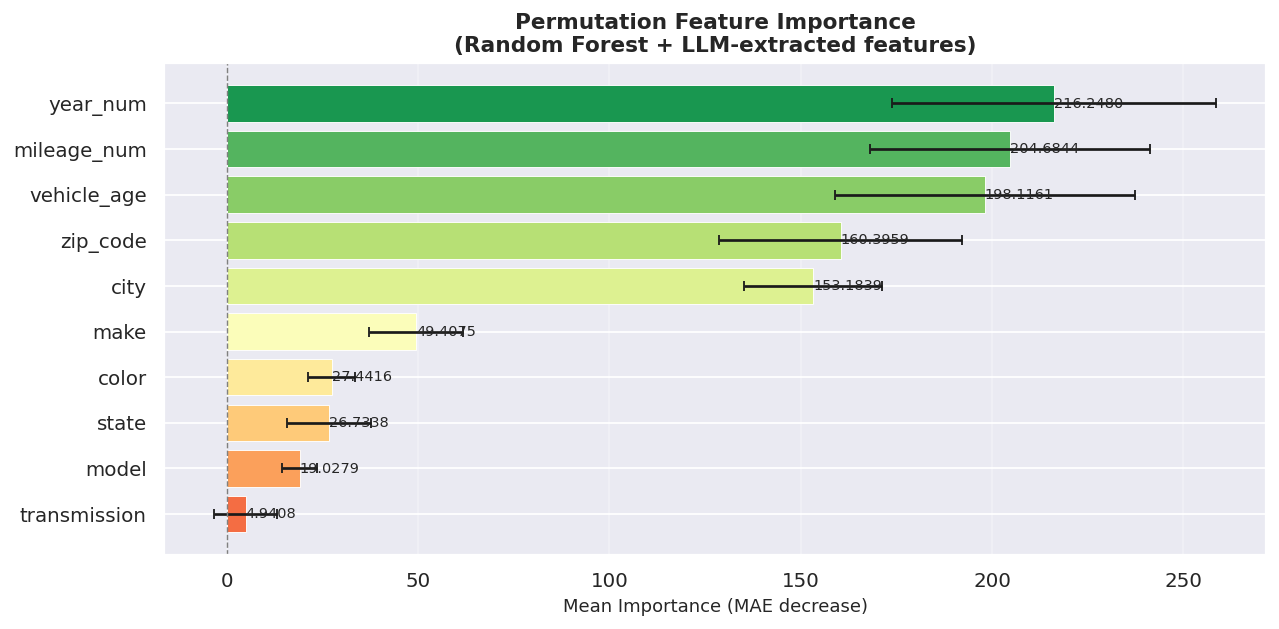

Top 3 Features:
  1. year_num             216.2480  (20.4% of total)
  2. mileage_num          204.6844  (19.3% of total)
  3. vehicle_age          198.1161  (18.7% of total)


In [7]:
def plot_feature_importance(results_dir):
    imp_path = os.path.join(results_dir, 'importance.csv')
    if not os.path.exists(imp_path):
        print(f'importance.csv not found at {imp_path}')
        return

    imp_df = pd.read_csv(imp_path).sort_values('importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(imp_df) * 0.5)))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp_df)))
    bars = ax.barh(imp_df['feature'], imp_df['importance'],
                   xerr=imp_df.get('std', None), color=colors,
                   capsize=3, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, imp_df['importance']):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_xlabel('Mean Importance (MAE decrease)', fontsize=10)
    ax.set_title('Permutation Feature Importance\n(Random Forest + LLM-extracted features)',
                 fontsize=12, fontweight='bold')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'dashboard_importance.png'), bbox_inches='tight', dpi=130)
    plt.show()

    top3 = imp_df.sort_values('importance', ascending=False).head(3)
    total = imp_df['importance'].sum()
    print('Top 3 Features:')
    for i, row in enumerate(top3.itertuples(), 1):
        pct = row.importance / total * 100 if total > 0 else 0
        print(f'  {i}. {row.feature:<20} {row.importance:.4f}  ({pct:.1f}% of total)')


plot_feature_importance(RESULTS_DIR)

## 7. Partial Dependence Plots (Top 3 Features)

PDPs show how changes in a single feature affect predicted price,
holding all other features constant.

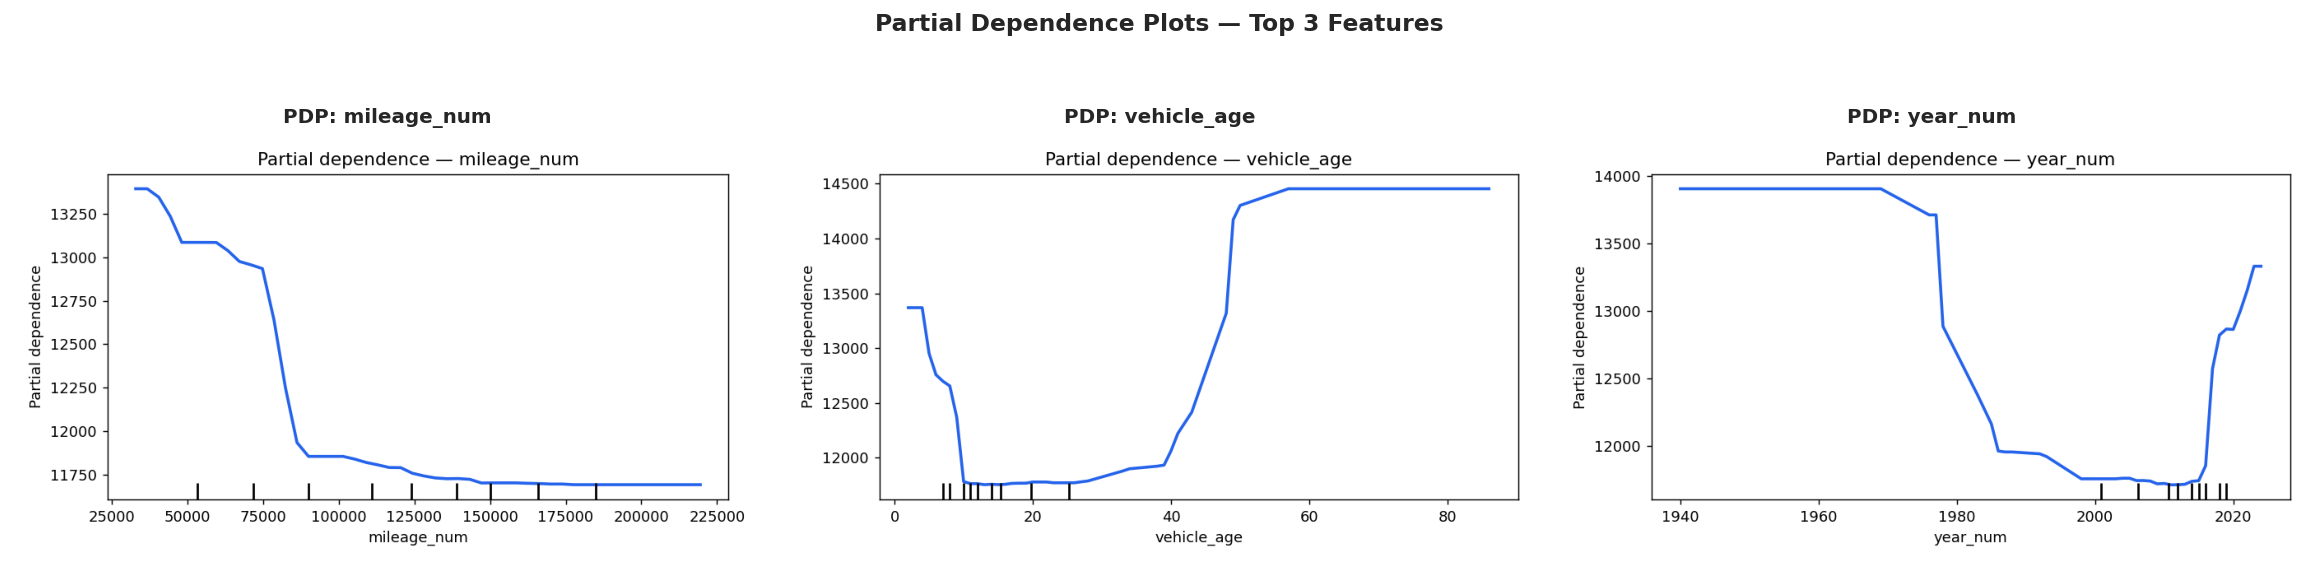

Showed 3 PDP plots


In [8]:
def show_pdp_plots(results_dir):
    pdp_files = sorted(glob.glob(os.path.join(results_dir, 'pdp_*.png')))
    if not pdp_files:
        print('No PDP plots found yet.')
        return
    n = len(pdp_files)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, pdp_path in zip(axes, pdp_files):
        img = plt.imread(pdp_path)
        ax.imshow(img)
        ax.axis('off')
        feat = os.path.basename(pdp_path).replace('pdp_', '').replace('.png', '')
        ax.set_title(f'PDP: {feat}', fontsize=11, fontweight='bold')
    plt.suptitle('Partial Dependence Plots — Top 3 Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'dashboard_pdp.png'), bbox_inches='tight', dpi=130)
    plt.show()
    print(f'Showed {n} PDP plots')


show_pdp_plots(RESULTS_DIR)

## 8. Dataset Growth vs Model Accuracy

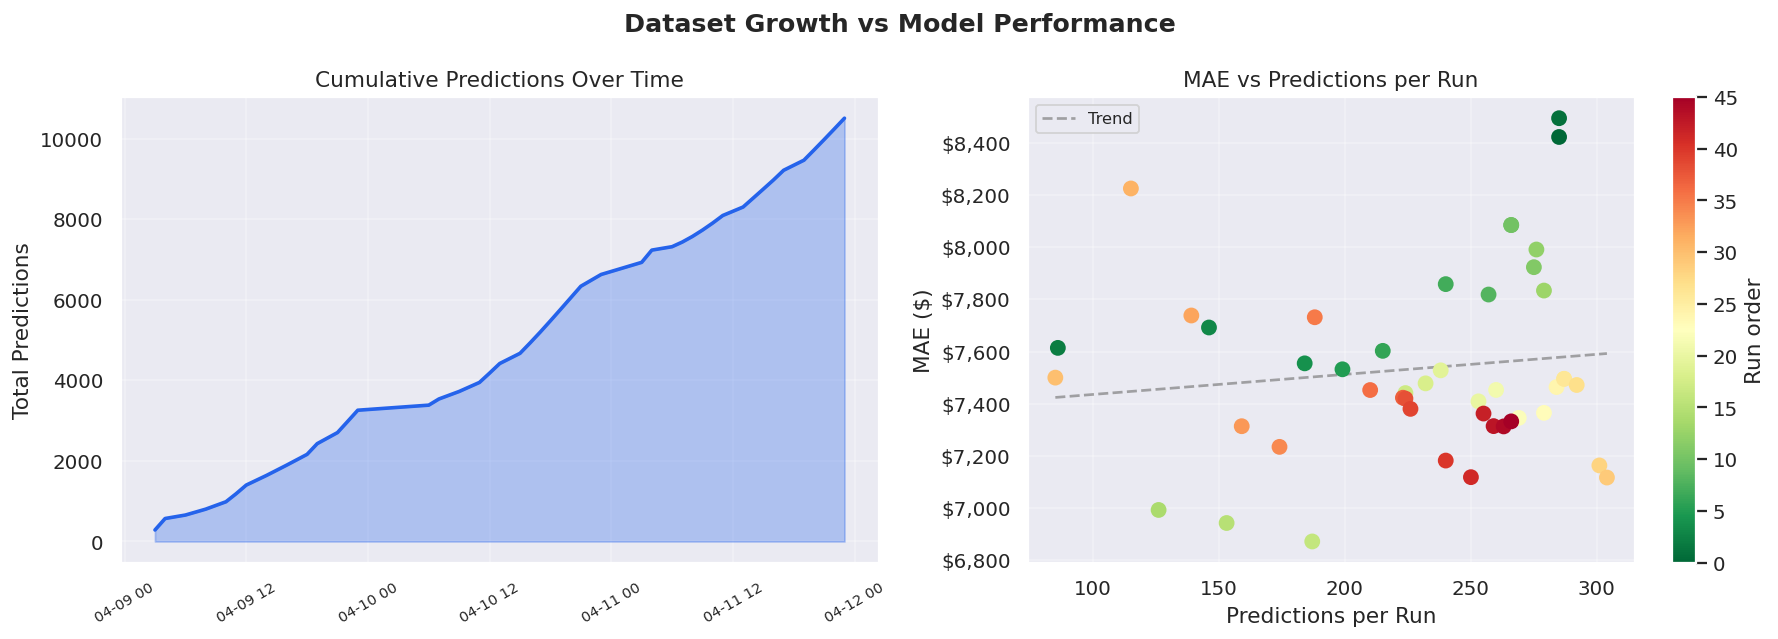

Saved dashboard_growth.png


In [9]:
def plot_growth_vs_accuracy(metrics_df):
    if metrics_df.empty or len(metrics_df) < 2:
        print('Need at least 2 runs to plot.')
        return

    m = metrics_df.copy()
    m['cumulative_preds'] = m['n_preds'].cumsum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Dataset Growth vs Model Performance', fontsize=14, fontweight='bold')

    ax1.fill_between(m['run_ts'], m['cumulative_preds'], alpha=0.3, color='#2563eb')
    ax1.plot(m['run_ts'], m['cumulative_preds'], color='#2563eb', linewidth=2)
    ax1.set_title('Cumulative Predictions Over Time')
    ax1.set_ylabel('Total Predictions')
    ax1.tick_params(axis='x', rotation=30, labelsize=8)
    ax1.grid(True, alpha=0.3)

    sc = ax2.scatter(m['n_preds'], m['MAE'], c=range(len(m)),
                     cmap='RdYlGn_r', s=60, zorder=5)
    if len(m) >= 3:
        z = np.polyfit(m['n_preds'], m['MAE'], 1)
        x_line = np.linspace(m['n_preds'].min(), m['n_preds'].max(), 100)
        ax2.plot(x_line, np.poly1d(z)(x_line), '--', color='gray', alpha=0.7, label='Trend')
        ax2.legend(fontsize=9)
    plt.colorbar(sc, ax=ax2, label='Run order')
    ax2.set_xlabel('Predictions per Run')
    ax2.set_ylabel('MAE ($)')
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax2.set_title('MAE vs Predictions per Run')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dashboard_growth.png'), bbox_inches='tight', dpi=130)
    plt.show()
    print('Saved dashboard_growth.png')


plot_growth_vs_accuracy(metrics_df)

## 9. Actual vs Predicted — Latest Run

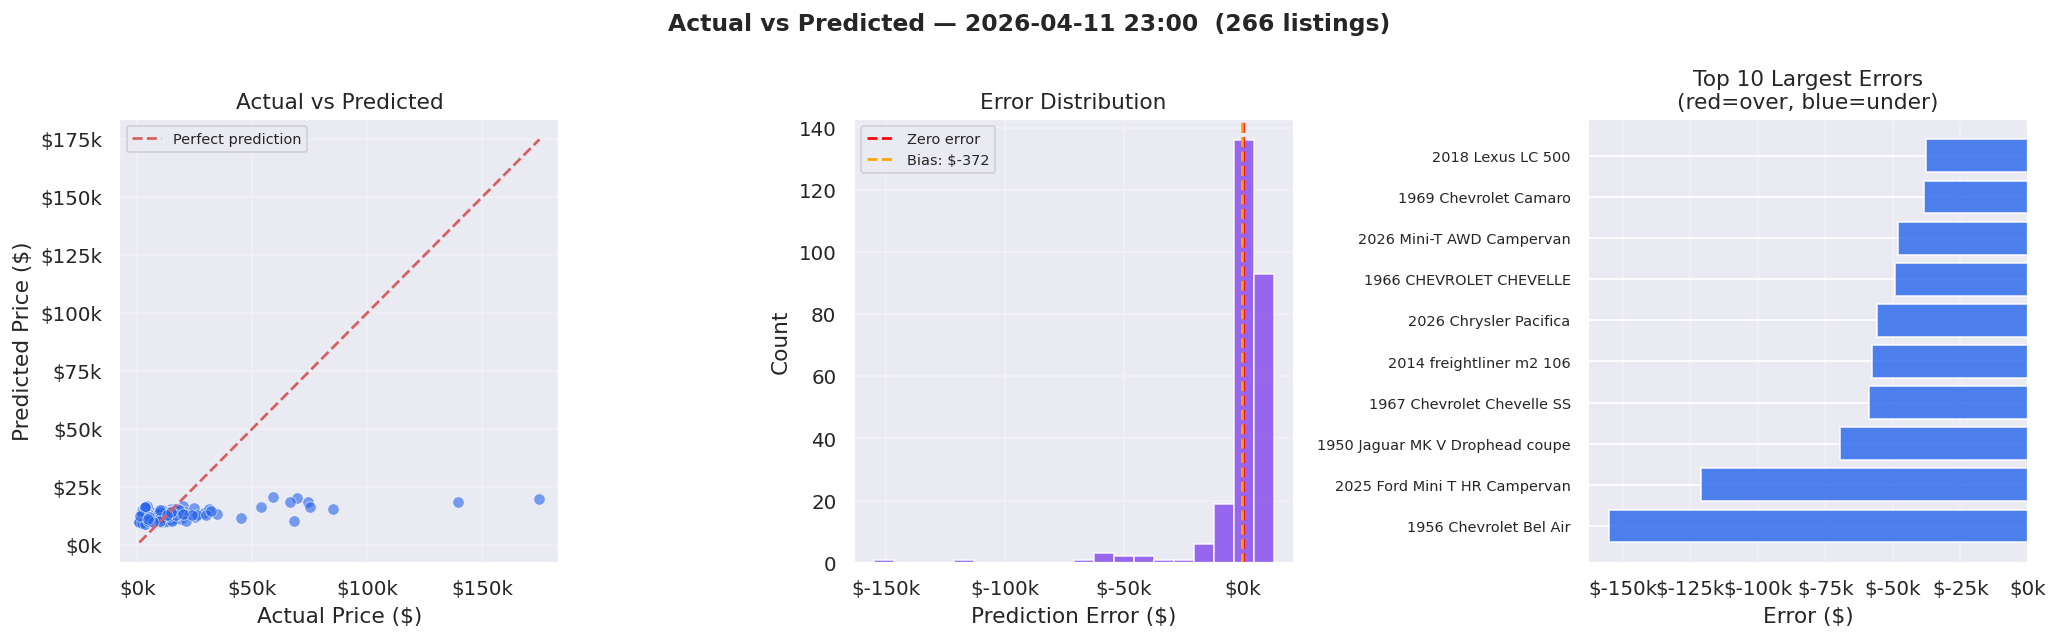

Saved dashboard_predictions.png


In [10]:
def plot_actual_vs_predicted(preds_df):
    if preds_df.empty:
        print('No predictions loaded.')
        return

    latest_run = preds_df['run_ts'].max()
    latest = preds_df[
        (preds_df['run_ts'] == latest_run) &
        preds_df['actual_price'].notna() & preds_df['pred_price'].notna()
    ].copy()
    if latest.empty:
        print('No valid predictions in latest run.')
        return

    latest['error']     = latest['pred_price'] - latest['actual_price']
    latest['abs_error'] = latest['error'].abs()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Actual vs Predicted — {latest_run.strftime("%Y-%m-%d %H:%M")}  ({len(latest)} listings)',
                 fontsize=13, fontweight='bold')

    # Scatter
    ax = axes[0]
    ax.scatter(latest['actual_price'], latest['pred_price'],
               alpha=0.6, color='#2563eb', s=40, edgecolors='white', linewidth=0.5)
    mn = min(latest['actual_price'].min(), latest['pred_price'].min())
    mx = max(latest['actual_price'].max(), latest['pred_price'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title('Actual vs Predicted')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Error distribution
    ax = axes[1]
    ax.hist(latest['error'], bins=20, color='#7c3aed', alpha=0.75, edgecolor='white')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
    ax.axvline(latest['error'].mean(), color='orange', linewidth=1.5, linestyle='--',
               label=f'Bias: ${latest["error"].mean():,.0f}')
    ax.set_xlabel('Prediction Error ($)')
    ax.set_ylabel('Count')
    ax.set_title('Error Distribution')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Top 10 worst predictions
    ax = axes[2]
    worst = latest.nlargest(10, 'abs_error').copy()
    worst['label'] = worst.apply(
        lambda r: f"{r['year']:.0f} {r['make']} {r['model']}", axis=1)
    colors_w = ['#dc2626' if e > 0 else '#2563eb' for e in worst['error']]
    ax.barh(range(len(worst)), worst['error'], color=colors_w, alpha=0.8)
    ax.set_yticks(range(len(worst)))
    ax.set_yticklabels(worst['label'], fontsize=8)
    ax.axvline(0, color='gray', linewidth=1)
    ax.set_xlabel('Error ($)')
    ax.set_title('Top 10 Largest Errors\n(red=over, blue=under)')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dashboard_predictions.png'), bbox_inches='tight', dpi=130)
    plt.show()
    print('Saved dashboard_predictions.png')


plot_actual_vs_predicted(preds_df)

## 10. Feature Patterns Over Time

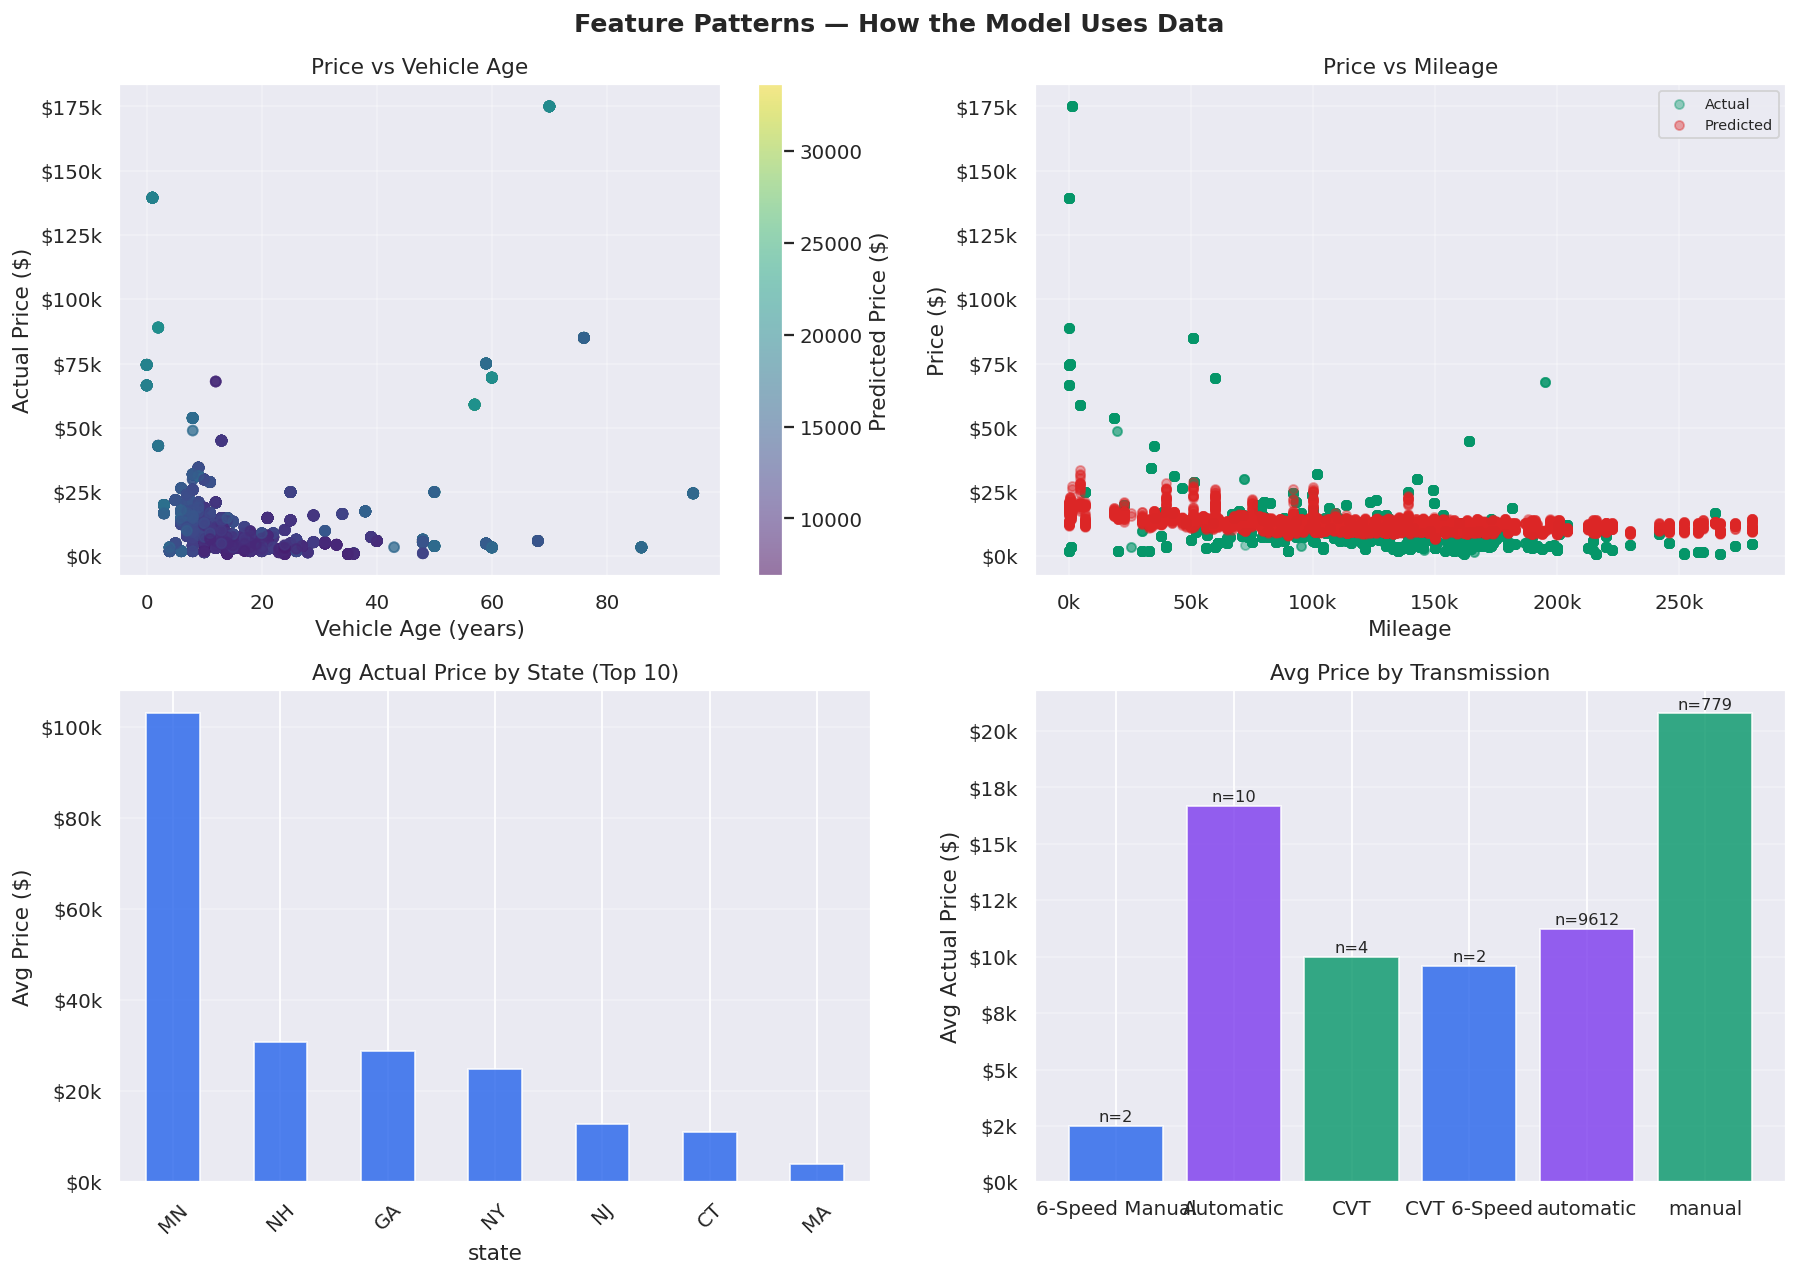

Saved dashboard_patterns.png


In [11]:
def plot_feature_patterns(preds_df):
    if preds_df.empty:
        print('No predictions loaded.')
        return

    valid = preds_df[preds_df['actual_price'].notna() & preds_df['pred_price'].notna()].copy()
    valid['vehicle_age'] = 2026 - pd.to_numeric(valid['year'], errors='coerce')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Feature Patterns — How the Model Uses Data', fontsize=14, fontweight='bold')

    # Price vs Vehicle Age
    ax = axes[0, 0]
    sc = ax.scatter(valid['vehicle_age'], valid['actual_price'],
                    c=valid['pred_price'], cmap='viridis', alpha=0.5, s=30)
    plt.colorbar(sc, ax=ax, label='Predicted Price ($)')
    ax.set_xlabel('Vehicle Age (years)')
    ax.set_ylabel('Actual Price ($)')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title('Price vs Vehicle Age')
    ax.grid(True, alpha=0.3)

    # Price vs Mileage
    ax = axes[0, 1]
    mv = valid[valid['mileage'].notna() & (valid['mileage'] < 300000)]
    ax.scatter(mv['mileage'], mv['actual_price'], alpha=0.4, color='#059669', s=25, label='Actual')
    ax.scatter(mv['mileage'], mv['pred_price'],   alpha=0.4, color='#dc2626', s=25, label='Predicted')
    ax.set_xlabel('Mileage')
    ax.set_ylabel('Price ($)')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.set_title('Price vs Mileage')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Avg price by state
    ax = axes[1, 0]
    sv = valid[valid['state'].notna() & (valid['state'] != 'unknown')]
    if not sv.empty:
        sv.groupby('state')['actual_price'].mean().sort_values(ascending=False).head(10) \
          .plot(kind='bar', ax=ax, color='#2563eb', alpha=0.8, edgecolor='white')
        ax.set_title('Avg Actual Price by State (Top 10)')
        ax.set_ylabel('Avg Price ($)')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.text(0.5, 0.5, 'No state data yet', ha='center', va='center', transform=ax.transAxes)
    ax.grid(True, axis='y', alpha=0.3)

    # Avg price by transmission
    ax = axes[1, 1]
    tv = valid[valid['transmission'].notna() & (valid['transmission'] != 'unknown')]
    if not tv.empty:
        tp = tv.groupby('transmission')['actual_price'].agg(['mean', 'count'])
        bars = ax.bar(tp.index, tp['mean'],
                      color=['#2563eb', '#7c3aed', '#059669'][:len(tp)],
                      alpha=0.8, edgecolor='white')
        for bar, (_, row) in zip(bars, tp.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'n={row["count"]:.0f}', ha='center', fontsize=9)
        ax.set_title('Avg Price by Transmission')
        ax.set_ylabel('Avg Actual Price ($)')
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    else:
        ax.text(0.5, 0.5, 'No transmission data yet', ha='center', va='center', transform=ax.transAxes)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'dashboard_patterns.png'), bbox_inches='tight', dpi=130)
    plt.show()
    print('Saved dashboard_patterns.png')


plot_feature_patterns(preds_df)

## 11. Final Summary

In [12]:
def final_summary(metrics_df, preds_df):
    print('=' * 60)
    print('  CAR PRICE PREDICTION — FINAL SUMMARY')
    print('=' * 60)
    if not metrics_df.empty:
        l    = metrics_df.iloc[-1]
        best = metrics_df.loc[metrics_df['MAE'].idxmin()]
        print(f'\nCURRENT PERFORMANCE (latest run):')
        print(f'  MAE  : ${l["MAE"]:>10,.0f}')
        print(f'  RMSE : ${l["RMSE"]:>10,.0f}')
        print(f'  MAPE : {l["MAPE"]:>10.1f}%')
        print(f'  Bias : ${l["Bias"]:>+10,.0f}  ({"over-predicts" if l["Bias"] > 0 else "under-predicts"})')
        print(f'  Preds: {l["n_preds"]:>10.0f}')
        print(f'\nBEST MAE EVER: ${best["MAE"]:,.0f}  (run {best["run_id"]})')
        print(f'TOTAL RUNS   : {len(metrics_df)}')
        print(f'DATE RANGE   : {metrics_df["run_ts"].min().date()} → {metrics_df["run_ts"].max().date()}')
    if not preds_df.empty:
        print(f'\nDATASET:')
        print(f'  Total predictions : {len(preds_df)}')
        print(f'  Unique listings   : {preds_df["post_id"].nunique()}')
    print('\nMODEL IMPROVEMENTS OVER BASELINE:')
    print('  Baseline Decision Tree MAE : ~$7,757')
    if not metrics_df.empty:
        improvement = (7757 - metrics_df['MAE'].min()) / 7757 * 100
        print(f'  Best RF + LLM features MAE : ${metrics_df["MAE"].min():,.0f}  ({improvement:.1f}% improvement)')
    print('\nNEW LLM-EXTRACTED FEATURES ADDED:')
    print('  color, city, state, zip_code')
    print('=' * 60)


final_summary(metrics_df, preds_df)

  CAR PRICE PREDICTION — FINAL SUMMARY

CURRENT PERFORMANCE (latest run):
  MAE  : $     7,332
  RMSE : $    16,370
  MAPE :      110.0%
  Bias : $      -372  (under-predicts)
  Preds:        266

BEST MAE EVER: $6,872  (run 2026041009)
TOTAL RUNS   : 46
DATE RANGE   : 2026-04-09 → 2026-04-11

DATASET:
  Total predictions : 10898
  Unique listings   : 361

MODEL IMPROVEMENTS OVER BASELINE:
  Baseline Decision Tree MAE : ~$7,757
  Best RF + LLM features MAE : $6,872  (11.4% improvement)

NEW LLM-EXTRACTED FEATURES ADDED:
  color, city, state, zip_code


---
## Notes

- **Data source:** Craigslist CT/NY listings scraped hourly via Cloud Scheduler
- **LLM extraction:** Gemini 2.5 Flash extracts `color`, `city`, `state`, `zip_code` from raw listing text
- **Model:** Random Forest Regressor tuned with Optuna (20 trials/run)
- **Train/test split:** All dates before today → train; today's listings → holdout
- **Baseline:** Decision Tree (MAE ~$7,757)
- **Improved model:** Random Forest + LLM features


**Challenges & Solutions:**

•	Billing issues delayed the pipeline early on, resulting in insufficient data for model training

•	Limited run history (only 2 run IDs initially) required batch-processing of historical runs to build an adequate dataset

•	Model returned noop — resolved by extracting backdated data to enable a proper train/test split

•	Materializer timeout on 292 folders — fixed by adding a max_runs parameter to limit the scope of processing


**Learnings:**

•	Sufficient data quality directly impacts model performance — backfilling data was unavoidable given the billing delays early in the pipeline

•	Mismatched folder and file names can be painful and hard to debug, especially at scale (e.g., materializer timeout across 292 folders)

•	Silent failures from wrong environment variables and missing packages cost hours — the pipeline appears to run fine but produces incorrect or empty results

•	City/state features revealed local market pricing patterns that the baseline Decision Tree completely missed, contributing significantly to the 11.4% MAE improvement
